In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import keras
import keras.backend as K
import sys
import uqmodels as uqmodels

path = '.'
storing = path + '/data/'


2025-12-05 16:25:05.171099: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-05 16:25:05.186346: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764951905.203931  580693 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764951905.209390  580693 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-05 16:25:05.227510: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
import uqmodels.processing as proc 
import uqmodels.preprocessing.Preprocessor as preproc
from uqmodels.processing import Data_loader
from uqmodels.processing import Pipeline
from uqmodels.preprocessing.Custom_Preprocessor import dict_to_TS_Dataset
import pandas as pd

#Data loading & Preprocessing
storing = 'data/'
filename = 'synthetic_dataset_multivariate.p'

# Instanciate Data_loader 
data_loader = Data_loader()

# Apply data_loader to get rowdata
dict_data = data_loader.load({'storing':storing,'keys':[filename]})
preprocessor = dict_to_TS_Dataset()
pipeline = Pipeline(data_loader=data_loader,list_processors=[preprocessor])
#Define query link to load api and add a 'name' key which is recover by the preprocessor to provide a name to the dataset
list_query = [{'storing':storing,'keys':[filename],'name':'Synthetic_data'}]

#It provide a data_generator (yield) that provide each processed data one by one.
dataset_generator = pipeline.transform(list_query) 

# Execute preprocessing pipeline :  
X, y, sample_weight, x_split, context, objective, name = next(dataset_generator)
train = x_split==1
test = np.invert(train)
print('X shape:',X.shape,'y: yshape',y.shape,'Name:',name)

Pipeline : No cache data found : load data and execute the whole pipeline
X shape: (12000, 19) y: yshape (12000, 3) Name: Synthetic_data


# RF-UQ 

Root mean square [array([0.35454324, 0.30451329, 0.31963972]), array([0.46449333, 0.40585166, 0.43980308])]
UQ_average_coverage [array([0.994   , 0.9955  , 0.995375]), array([0.97825, 0.97675, 0.97675])]


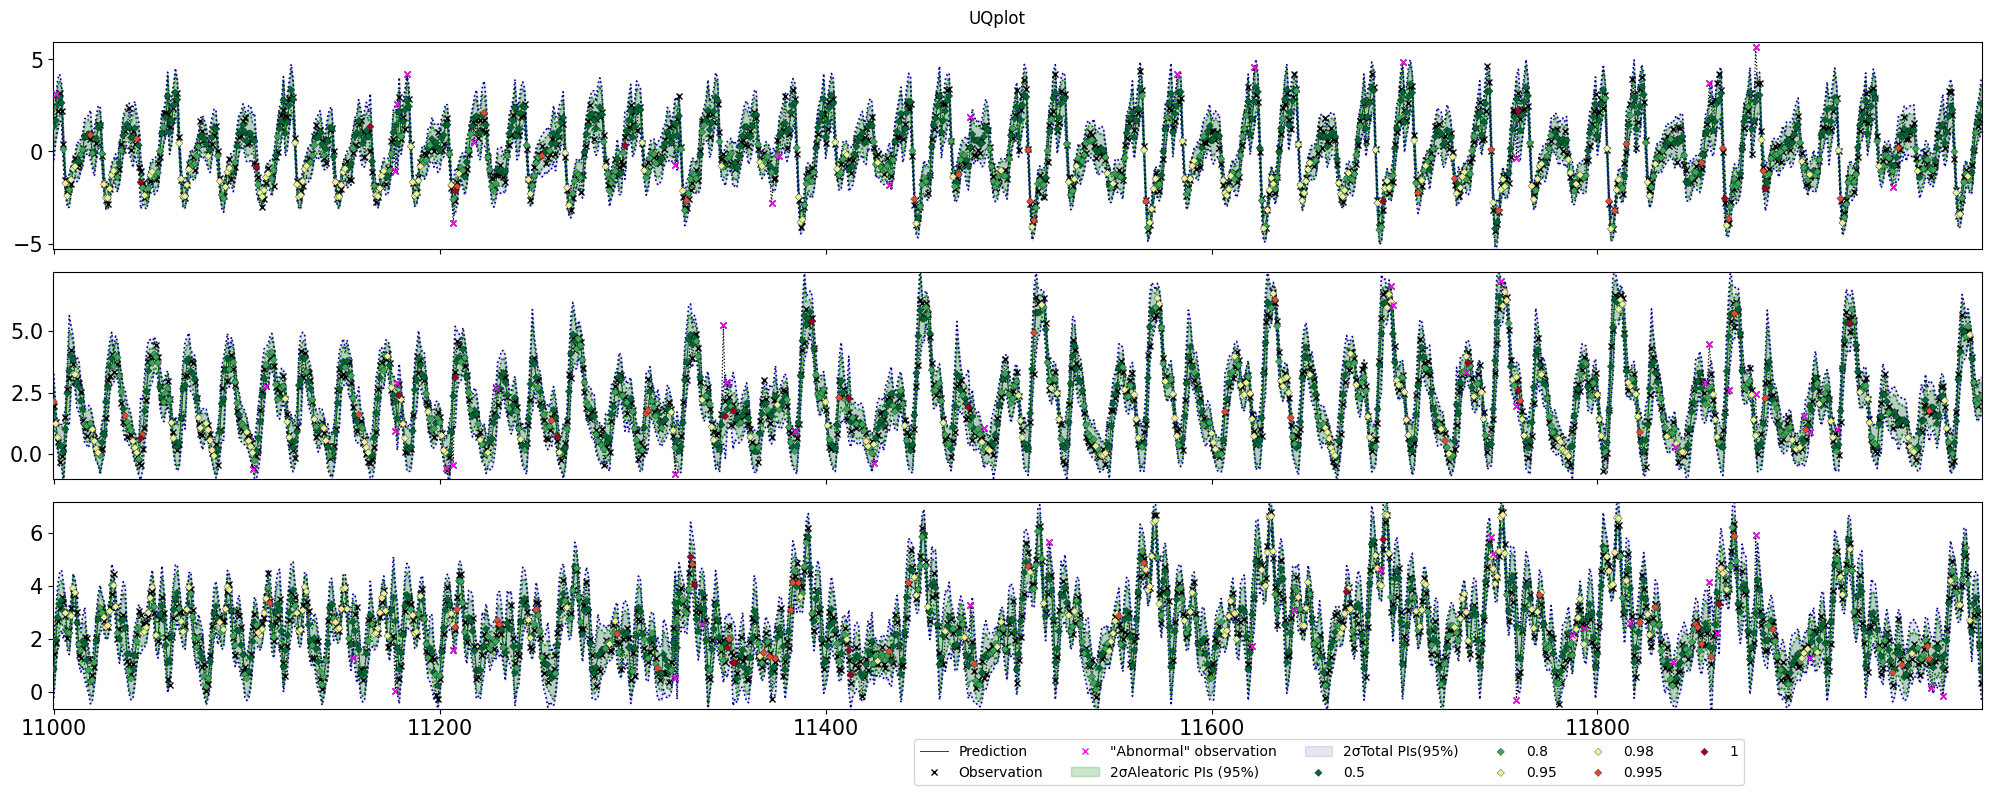

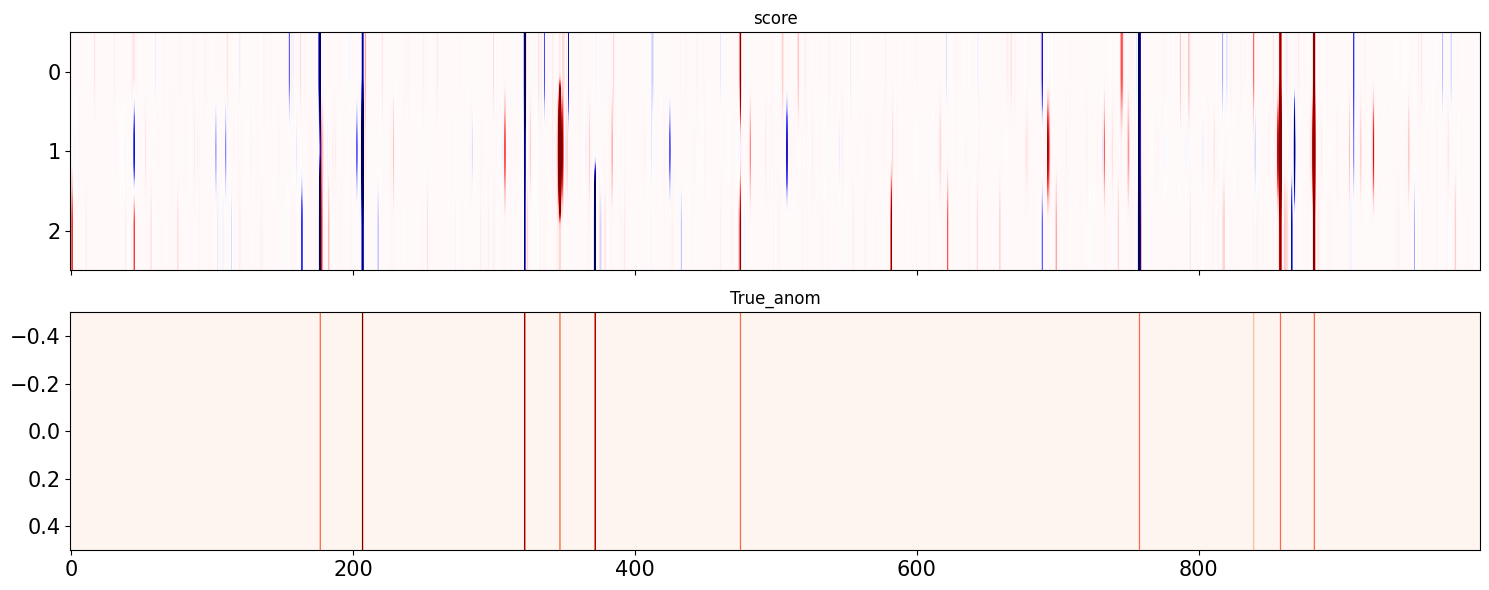

target [0.025, 0.16, 0.84, 0.975] empirique [0.006027777777777778, 0.07030555555555555, 0.9316666666666666, 0.9941388888888889]
target elvl [0.5, 0.8, 0.95, 0.98, 0.995, 1] empirique Elvl [0.0, 2.0, 3.0, 4.0, 5.0, 6.0]


In [3]:
from uqmodels.modelization.ML_estimator.random_forest_UQ import RF_UQEstimator,get_params_dict
from uqmodels.processing import Cache_manager
from uqmodels.custom_UQModel import UQModel_KPI,UQModel
# We can also create a more complexe UQmodel that handle several UQKPI_Processor to build at inference (UQMesure, Predictive interval and model unreliability score) and after observation (Anomaly score)

# Specification of the UQestimator & Instanciation in a UQmodels wrapper that include post-processing
RF_UQ_parameters = get_params_dict()
RF_UQModel = UQModel_KPI(RF_UQEstimator,
                         RF_UQ_parameters,
                         name='RF_UQ',
                         beta=0.005,
                         reduc_filter_KPI=None,
                         reduc_filter_pred=None,
                         cache_manager=Cache_manager(storing='model/'),
                         random_state=0)

RF_UQModel.fit(X[train],y[train])
if(True): # Test load save UQModels wrapper procedure
    # Save fitted UQEstimator and KPI-Processors
    RF_UQModel.save('model/')
    del RF_UQModel
    # New model 
    RF_UQModel = UQModel()

    # Load fitted UQEstimator and KPI-Processors
    RF_UQModel.load('model/RF_UQ')

#pred,((pred,UQ),PIs,Elvl) = RF_UQModel.predict(X,y)
(pred,UQ),KPI_anom,PIs,Elvl = RF_UQModel.score(X,y)

from uqmodels.evaluation.metrics import Generic_metric, rmse, UQ_average_coverage, UQ_sharpness, UQ_Gaussian_NLL, UQ_dEI, UQ_absolute_residu_score
from uqmodels.evaluation.evaluation import evaluate

if(True):
    list_metrics=[Generic_metric(rmse,'Root mean square',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E'),
                  Generic_metric(UQ_average_coverage,'UQ_average_coverage',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E')]
    output = pred,UQ
    metrics_val = evaluate(y,output,list_metrics,list_sets=[train,test],verbose=True)
    
%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import uqmodels.visualization.visualization as visu

f_obs = np.arange(len(train))[-1000:]
list_percent = RF_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
visu.uncertainty_plot(y,output,context=None,size=(20,8),f_obs=f_obs,name='UQplot',mode_res=False,dim=np.arange(y.shape[1]),type_UQ=RF_UQModel.type_UQ,list_percent=list_percent)
visu.plot_anom_matrice(score=KPI_anom,true_label=dict_data['aux']['anom'][:,None],f_obs=f_obs)

list_alpha = RF_UQModel.list_predict_KPI_processors[1].KPI_parameters['list_alpha']
print('target', list_alpha, 'empirique', [(pi>y).mean() for pi in PIs])
list_percent = RF_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
print('target elvl',list_percent,'empirique Elvl',[np.quantile(Elvl,q) for q in list_percent])
del RF_UQModel

In [4]:
list_percent

[0.5, 0.8, 0.95, 0.98, 0.995, 1]

# NN_UQ for multi meta-moddeling paradigm 

In [5]:
#tf.keras.utils.get_custom_objects().clear()
from uqmodels.modelization.DL_estimator.neural_network_UQ import NN_UQ,get_params_dict,get_training_parameters
from uqmodels.modelization.UQEstimator import get_UQEstimator_parameters
from uqmodels.modelization.DL_estimator.metalayers import mlp
from uqmodels.processing import Cache_manager
from uqmodels.UQModel import UQModel
from uqmodels.custom_UQModel import UQModel_KPI
# We can also create a more complexe UQmodel that handle several UQKPI_Processor to build at inference (UQMesure, Predictive interval and model unreliability score) and after observation (Anomaly score)

# Specification of the UQestimator & Instanciation in a UQmodels wrapper that include post-processing
    
def run_mlp(type_output='MC_Dropout'):
    name = 'MLP_'+type_output
    print(type_output)
    mlp_params = get_params_dict(X.shape[1],y.shape[1],type_output=type_output)
    training_params = get_training_parameters(epochs=[20,10],b_s=[128,64],l_r=[0.001,0.0005],type_output=type_output)

    UQEstimator_parameters = get_UQEstimator_parameters(model_parameters=mlp_params, 
                                                    training_parameters=training_params,
                                                    type_output=type_output,
                                                    rescale=True,
                                                    model_initializer=mlp)

    MLP_UQModel = UQModel_KPI(UQEstimator_initializer=NN_UQ,
                             UQEstimator_params=UQEstimator_parameters,
                             name=name,
                             beta=0.005,
                             reduc_filter_KPI=None,
                             reduc_filter_pred=None,
                             cache_manager=Cache_manager(storing='model/'),
                             random_state=0)


    MLP_UQModel.fit(X[train],y[train],verbose=1)
    
    if(True): # Test save load procedure 
        MLP_UQModel.save('model/')
        del MLP_UQModel
        MLP_UQModel = UQModel()
        MLP_UQModel.load('model/'+name)
        
    #pred,((pred,UQ),PIs,Elvl) = RF_UQModel.predict(X,y)
    (pred,UQ),KPI_anom,PIs,Elvl = MLP_UQModel.score(X,y)

    from uqmodels.evaluation.metrics import Generic_metric, rmse, UQ_average_coverage, UQ_sharpness, UQ_Gaussian_NLL, UQ_dEI, UQ_absolute_residu_score
    from uqmodels.evaluation.evaluation import evaluate

    if(True):
        list_metrics=[Generic_metric(rmse,'Root mean square',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E'),
                      Generic_metric(UQ_average_coverage,'UQ_average_coverage',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E')]
        output = pred,UQ
        metrics_val = evaluate(y,output,list_metrics,list_sets=[train,test],verbose=True)

    %matplotlib notebook
    %matplotlib inline
    import matplotlib.pyplot as plt
    import uqmodels.visualization.visualization as visu

    f_obs = np.arange(len(train))[-1000:]
    list_percent = MLP_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
    visu.uncertainty_plot(y,output,context=None,size=(20,8),f_obs=f_obs,name='UQplot',mode_res=False,dim=np.arange(y.shape[1]),type_UQ=MLP_UQModel.type_UQ,list_percent=list_percent,confidence_lvl=Elvl)
    visu.plot_anom_matrice(score=KPI_anom,true_label=dict_data['aux']['anom'][:,None],f_obs=f_obs)

    list_alpha = MLP_UQModel.list_predict_KPI_processors[1].KPI_parameters['list_alpha']
    print('target', list_alpha, 'empirique', [(pi>y).mean() for pi in PIs])
    list_percent = MLP_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
    print('target elvl',list_percent,'empirique Elvl',[np.quantile(Elvl,q) for q in list_percent])
    print(list_percent)
    del MLP_UQModel

In [6]:
# MLP_UQ_MC_Dropout

MC_Dropout
start_fit


/home/jovyan/Maturation/env-uqmodels/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
I0000 00:00:1764951942.505381  580693 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29930 MB memory:  -> device: 0, name: Tesla V100-PCIE-32GB, pci bus id: 0000:18:00.0, compute capability: 7.0
I0000 00:00:1764951942.505871  580693 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 31134 MB memory:  -> device: 1, name: Tesla V100-PCIE-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0


Epoch 1/20


2025-12-05 16:25:43.363177: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - bnn_loss: 0.9865 - loss: 0.4039 - mse_loss: 0.5819 - val_bnn_loss: 0.9989 - val_loss: 0.1723 - val_mse_loss: 0.3636 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9969 - loss: 0.2227 - mse_loss: 0.4288 - val_bnn_loss: 0.9993 - val_loss: 0.1533 - val_mse_loss: 0.3362 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9980 - loss: 0.2007 - mse_loss: 0.4033 - val_bnn_loss: 0.9989 - val_loss: 0.1452 - val_mse_loss: 0.3248 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9987 - loss: 0.1874 - mse_loss: 0.3870 - val_bnn_loss: 0.9993 - val_loss: 0.1392 - val_mse_loss: 0.3154 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9985 - loss: 0.1778 - mse_loss: 0.3751 - val_bnn_loss: 0.9993 - val_loss: 0.1342 - val_mse_loss: 0.3083 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step -

...

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - bnn_loss: 0.9805 - loss: -0.6787 - mse_loss: 0.3394 - val_bnn_loss: 0.9889 - val_loss: -1.1891 - val_mse_loss: 0.2847 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9700 - loss: -1.0011 - mse_loss: 0.3324 - val_bnn_loss: 0.9881 - val_loss: -1.2836 - val_mse_loss: 0.2792 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9709 - loss: -1.0780 - mse_loss: 0.3245 - val_bnn_loss: 0.9881 - val_loss: -1.3121 - val_mse_loss: 0.2793 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9697 - loss: -1.1277 - mse_loss: 0.3197 - val_bnn_loss: 0.9877 - val_loss: -1.3230 - val_mse_loss: 0.2845 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9679 - loss: -1.1605 - mse_loss: 0.3145 - val_bnn_loss: 0.9862 - val_loss: -1.3660 - val_mse_loss: 0.2773 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 

2025-12-05 16:26:08.357777: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - bnn_loss: 0.9641 - loss: -1.3201 - mse_loss: 0.2967 - val_bnn_loss: 0.9800 - val_loss: -1.4768 - val_mse_loss: 0.2698 - learning_rate: 5.0000e-04
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - bnn_loss: 0.9646 - loss: -1.3213 - mse_loss: 0.2959 - val_bnn_loss: 0.9804 - val_loss: -1.4955 - val_mse_loss: 0.2708 - learning_rate: 5.0000e-04
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - bnn_loss: 0.9641 - loss: -1.3404 - mse_loss: 0.2937 - val_bnn_loss: 0.9808 - val_loss: -1.4886 - val_mse_loss: 0.2703 - learning_rate: 5.0000e-04
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - bnn_loss: 0.9645 - loss: -1.3379 - mse_loss: 0.2929 - val_bnn_loss: 0.9800 - val_loss: -1.4805 - val_mse_loss: 0.2721 - learning_rate: 5.0000e-04
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - bnn_loss: 0.9650 - loss: -1.3357 - mse_loss: 0.2944 - val_bnn_loss: 0.9824 - val_loss: -1.4663 - val_mse_loss: 0.2725 - learning_rate: 5.0000e-04
Epoch 6/10


/home/jovyan/Maturation/env-uqmodels/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/jovyan/Maturation/env-uqmodels/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step
Root mean square [array([0.41466094, 0.35703857, 0.38279795]), array([0.45694397, 0.38859082, 0.4298772 ])]
UQ_average_coverage [array([0.983625, 0.9855  , 0.985875]), array([0.97525, 0.97675, 0.9755 ])]


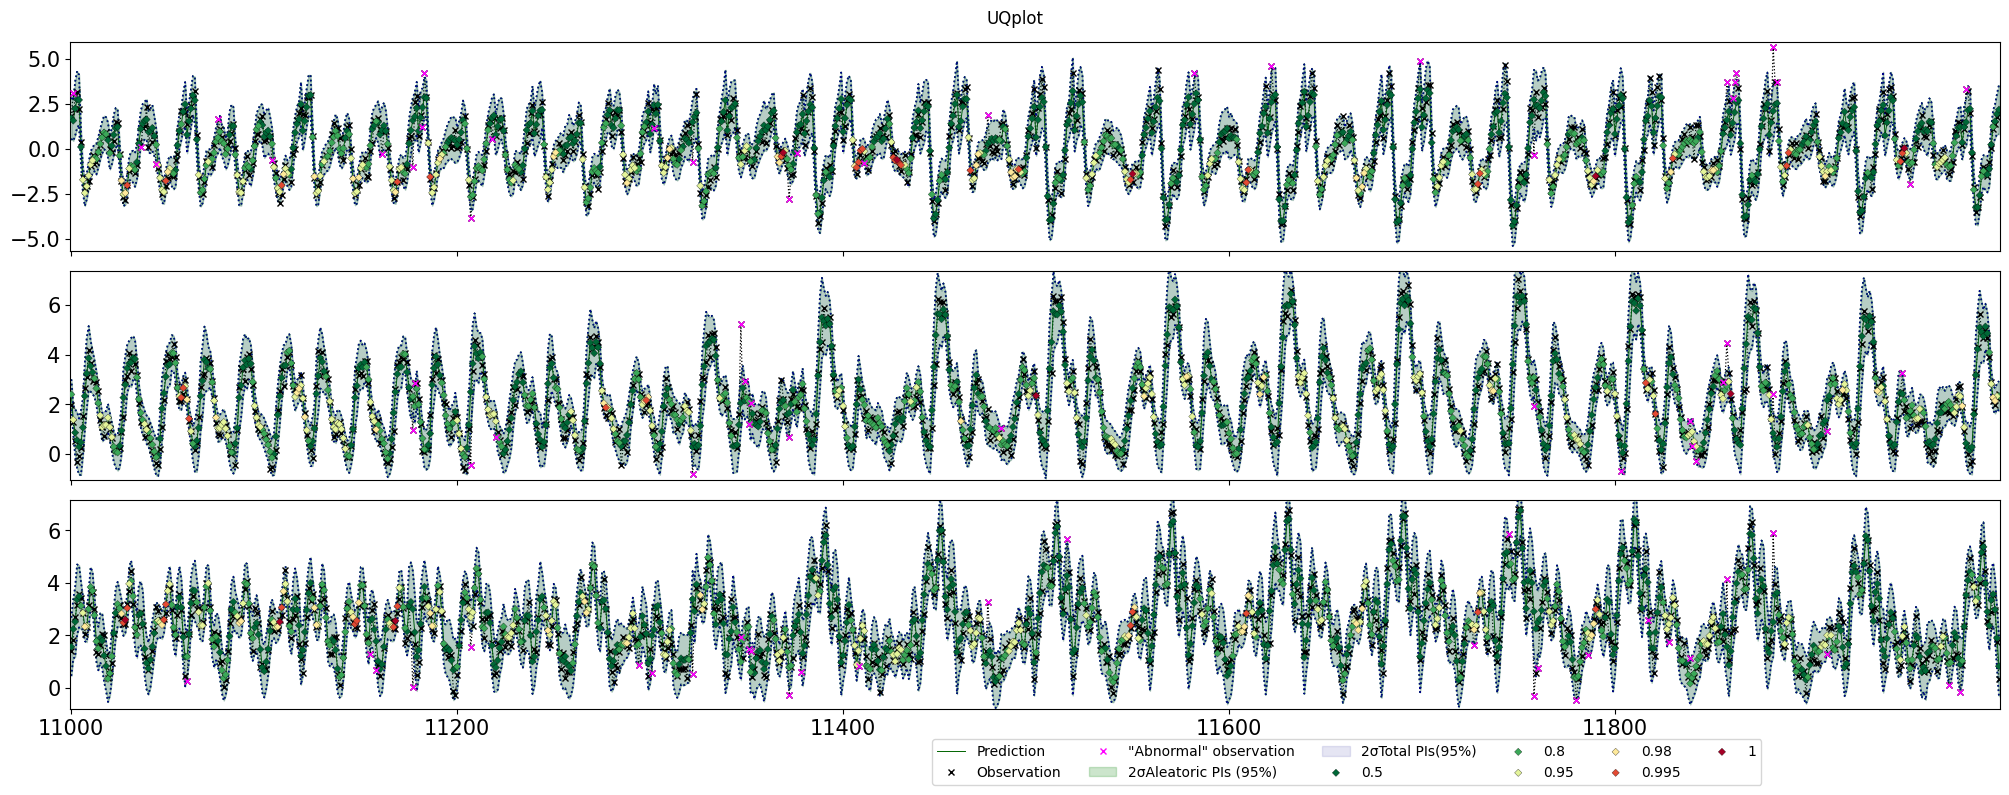

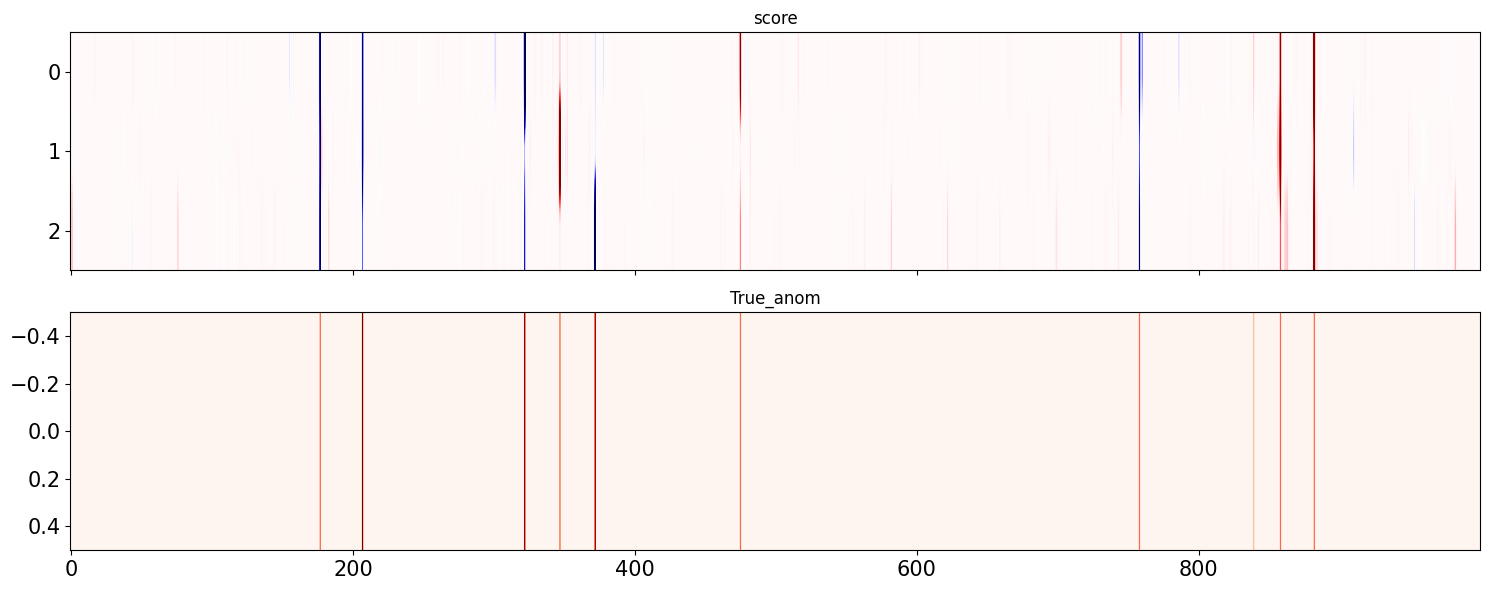

target [0.025, 0.16, 0.84, 0.975] empirique [0.011027777777777777, 0.10347222222222222, 0.9170833333333334, 0.9911944444444445]
target elvl [0.5, 0.8, 0.95, 0.98, 0.995, 1] empirique Elvl [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
[0.5, 0.8, 0.95, 0.98, 0.995, 1]


In [7]:
run_mlp(type_output='MC_Dropout')

# MLP_UQ_Deep_ensemble

Deep_ensemble
start_fit


/home/jovyan/Maturation/env-uqmodels/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/20


2025-12-05 16:26:21.306202: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - bnn_loss: 0.9905 - loss: 0.3203 - mse_loss: 0.4989 - val_bnn_loss: 0.9989 - val_loss: 0.1602 - val_mse_loss: 0.3469 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9978 - loss: 0.1629 - mse_loss: 0.3524 - val_bnn_loss: 0.9993 - val_loss: 0.1414 - val_mse_loss: 0.3195 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9985 - loss: 0.1473 - mse_loss: 0.3302 - val_bnn_loss: 0.9979 - val_loss: 0.1336 - val_mse_loss: 0.3074 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9987 - loss: 0.1397 - mse_loss: 0.3194 - val_bnn_loss: 0.9989 - val_loss: 0.1284 - val_mse_loss: 0.2990 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9989 - loss: 0.1334 - mse_loss: 0.3102 - val_bnn_loss: 0.9989 - val_loss: 0.1241 - val_mse_loss: 0.2925 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step -

...

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - bnn_loss: 0.9771 - loss: -1.0140 - mse_loss: 0.2922 - val_bnn_loss: 0.9752 - val_loss: -1.4023 - val_mse_loss: 0.2745 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9695 - loss: -1.3453 - mse_loss: 0.2815 - val_bnn_loss: 0.9690 - val_loss: -1.4447 - val_mse_loss: 0.2746 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9686 - loss: -1.4183 - mse_loss: 0.2759 - val_bnn_loss: 0.9712 - val_loss: -1.4985 - val_mse_loss: 0.2699 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9680 - loss: -1.4674 - mse_loss: 0.2718 - val_bnn_loss: 0.9705 - val_loss: -1.4791 - val_mse_loss: 0.2737 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9670 - loss: -1.4840 - mse_loss: 0.2697 - val_bnn_loss: 0.9705 - val_loss: -1.5390 - val_mse_loss: 0.2672 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 

2025-12-05 16:28:47.622660: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - bnn_loss: 0.9657 - loss: -1.6880 - mse_loss: 0.2505 - val_bnn_loss: 0.9566 - val_loss: -1.5235 - val_mse_loss: 0.2727 - learning_rate: 5.0000e-04
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - bnn_loss: 0.9641 - loss: -1.6947 - mse_loss: 0.2512 - val_bnn_loss: 0.9605 - val_loss: -1.5238 - val_mse_loss: 0.2720 - learning_rate: 5.0000e-04
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - bnn_loss: 0.9652 - loss: -1.7007 - mse_loss: 0.2500 - val_bnn_loss: 0.9555 - val_loss: -1.5356 - val_mse_loss: 0.2709 - learning_rate: 5.0000e-04
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - bnn_loss: 0.9639 - loss: -1.7130 - mse_loss: 0.2486 - val_bnn_loss: 0.9554 - val_loss: -1.5232 - val_mse_loss: 0.2716 - learning_rate: 5.0000e-04
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - bnn_loss: 0.9637 - loss: -1.7167 - mse_loss: 0.2487 - val_bnn_loss: 0.9522 - val_loss: -1.5136 - val_mse_loss: 0.2727 - learning_rate: 5.0000e-04
Epoch 6/10


/home/jovyan/Maturation/env-uqmodels/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/jovyan/Maturation/env-uqmodels/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step
Root mean square [array([0.38008018, 0.3337588 , 0.35803565]), array([0.45434221, 0.38567763, 0.43973997])]
UQ_average_coverage [array([0.973   , 0.974625, 0.973625]), array([0.94475, 0.9435 , 0.942  ])]


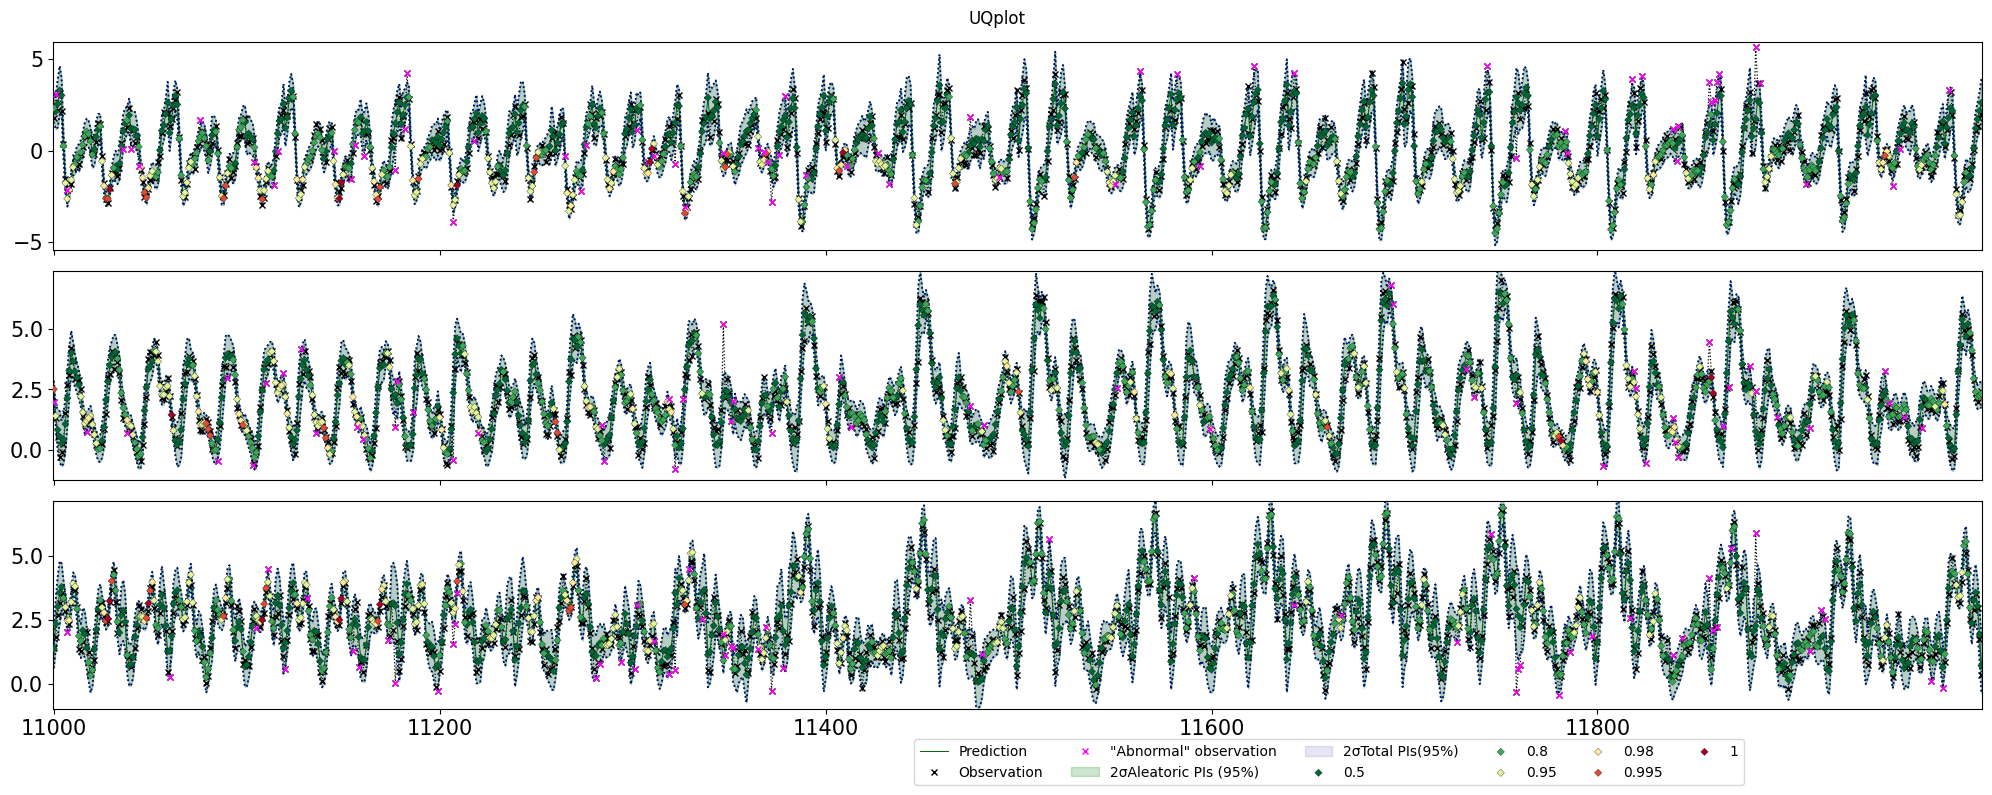

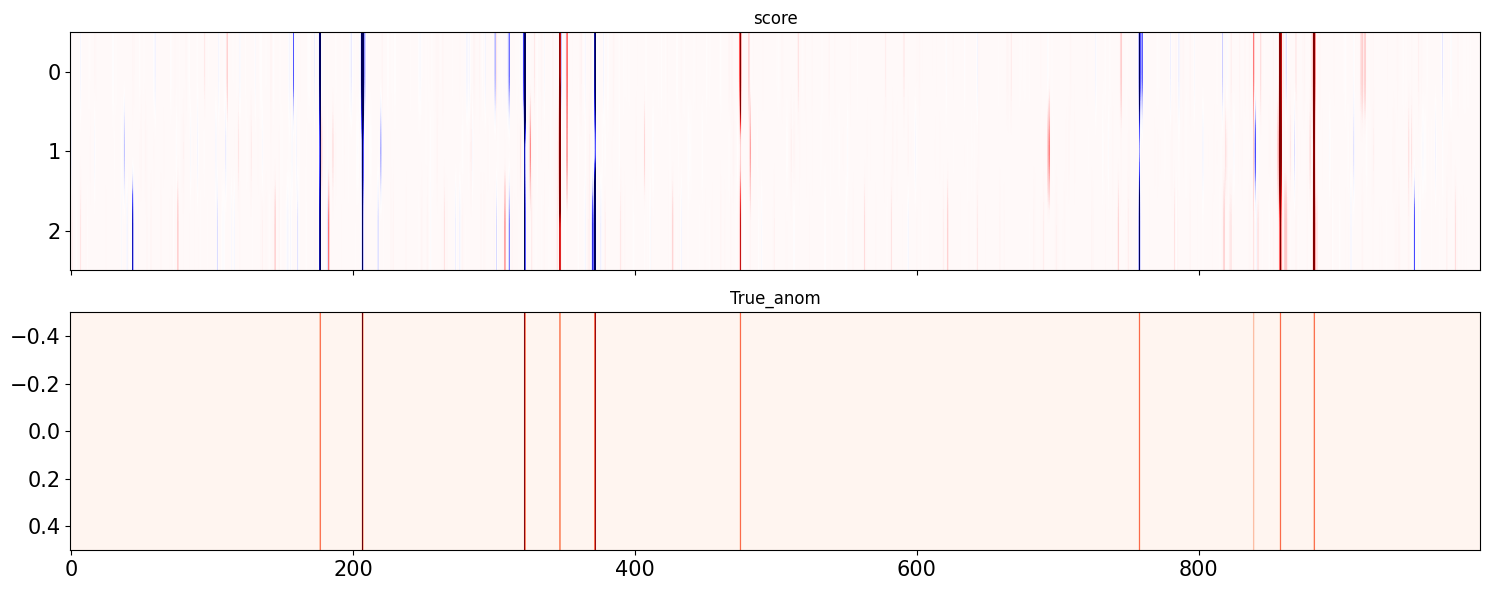

target [0.025, 0.16, 0.84, 0.975] empirique [0.024166666666666666, 0.16041666666666668, 0.8935555555555555, 0.9847222222222223]
target elvl [0.5, 0.8, 0.95, 0.98, 0.995, 1] empirique Elvl [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
[0.5, 0.8, 0.95, 0.98, 0.995, 1]


In [8]:
run_mlp(type_output='Deep_ensemble')

In [9]:
# MLP_UQ_Deep_ensemble

EDL
start_fit
Epoch 1/20


/home/jovyan/Maturation/env-uqmodels/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
2025-12-05 16:29:01.418146: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - bnn_loss: 0.9944 - loss: 0.3248 - mse_loss: 0.5013 - val_bnn_loss: 0.9985 - val_loss: 0.1589 - val_mse_loss: 0.3442 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9984 - loss: 0.1602 - mse_loss: 0.3484 - val_bnn_loss: 0.9993 - val_loss: 0.1416 - val_mse_loss: 0.3195 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9986 - loss: 0.1461 - mse_loss: 0.3286 - val_bnn_loss: 0.9989 - val_loss: 0.1341 - val_mse_loss: 0.3070 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9989 - loss: 0.1388 - mse_loss: 0.3178 - val_bnn_loss: 0.9996 - val_loss: 0.1277 - val_mse_loss: 0.2970 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - bnn_loss: 0.9989 - loss: 0.1336 - mse_loss: 0.3101 - val_bnn_loss: 0.9996 - val_loss: 0.1234 - val_mse_loss: 0.2902 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step -

2025-12-05 16:29:09.926718: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - bnn_loss: 0.9995 - loss: 0.1040 - mse_loss: 0.2682 - val_bnn_loss: 0.9996 - val_loss: 0.1076 - val_mse_loss: 0.2738 - learning_rate: 5.0000e-04
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - bnn_loss: 0.9994 - loss: 0.1033 - mse_loss: 0.2673 - val_bnn_loss: 0.9996 - val_loss: 0.1078 - val_mse_loss: 0.2747 - learning_rate: 5.0000e-04
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - bnn_loss: 0.9994 - loss: 0.1020 - mse_loss: 0.2653 - val_bnn_loss: 0.9996 - val_loss: 0.1067 - val_mse_loss: 0.2732 - learning_rate: 5.0000e-04
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - bnn_loss: 0.9995 - loss: 0.1016 - mse_loss: 0.2650 - val_bnn_loss: 0.9996 - val_loss: 0.1061 - val_mse_loss: 0.2727 - learning_rate: 5.0000e-04
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - bnn_loss: 0.9995 - loss: 0.1008 - mse_loss: 0.2642 - val_bnn_loss: 0.9996 - val_loss: 0.1063 - val_mse_loss: 0.2737 - learning_rate: 5.0000e-04
Epoch 6/10
113/113 ━━

...

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - bnn_loss: 0.8431 - loss: -0.0060 - mse_loss: 0.2500 - val_bnn_loss: 0.7929 - val_loss: 0.0814 - val_mse_loss: 0.2697 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - bnn_loss: 0.8267 - loss: -0.0222 - mse_loss: 0.2491 - val_bnn_loss: 0.7791 - val_loss: 0.0878 - val_mse_loss: 0.2706 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - bnn_loss: 0.8088 - loss: -0.0310 - mse_loss: 0.2496 - val_bnn_loss: 0.7605 - val_loss: 0.0874 - val_mse_loss: 0.2727 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - bnn_loss: 0.7967 - loss: -0.0380 - mse_loss: 0.2483 - val_bnn_loss: 0.7330 - val_loss: 0.0861 - val_mse_loss: 0.2714 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - bnn_loss: 0.7802 - loss: -0.0413 - mse_loss: 0.2478 - val_bnn_loss: 0.7006 - val_loss: 0.0871 - val_mse_loss: 0.2739 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/s

2025-12-05 16:29:43.556043: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - bnn_loss: 0.6327 - loss: -0.0986 - mse_loss: 0.2417 - val_bnn_loss: 0.5589 - val_loss: 0.0714 - val_mse_loss: 0.2720 - learning_rate: 5.0000e-04
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - bnn_loss: 0.6234 - loss: -0.1074 - mse_loss: 0.2404 - val_bnn_loss: 0.5407 - val_loss: 0.0807 - val_mse_loss: 0.2734 - learning_rate: 5.0000e-04
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - bnn_loss: 0.6190 - loss: -0.1039 - mse_loss: 0.2406 - val_bnn_loss: 0.5513 - val_loss: 0.0722 - val_mse_loss: 0.2720 - learning_rate: 5.0000e-04
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - bnn_loss: 0.6169 - loss: -0.1115 - mse_loss: 0.2399 - val_bnn_loss: 0.5306 - val_loss: 0.0880 - val_mse_loss: 0.2743 - learning_rate: 5.0000e-04
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - bnn_loss: 0.6127 - loss: -0.1124 - mse_loss: 0.2395 - val_bnn_loss: 0.5267 - val_loss: 0.0729 - val_mse_loss: 0.2723 - learning_rate: 5.0000e-04
Epoch 6/10
113/1

/home/jovyan/Maturation/env-uqmodels/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/jovyan/Maturation/env-uqmodels/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step
Root mean square [array([0.37097621, 0.32406045, 0.34388175]), array([0.45506162, 0.3865774 , 0.44016922])]
UQ_average_coverage [array([0.978375, 0.979125, 0.981   ]), array([0.9515 , 0.93925, 0.95175])]


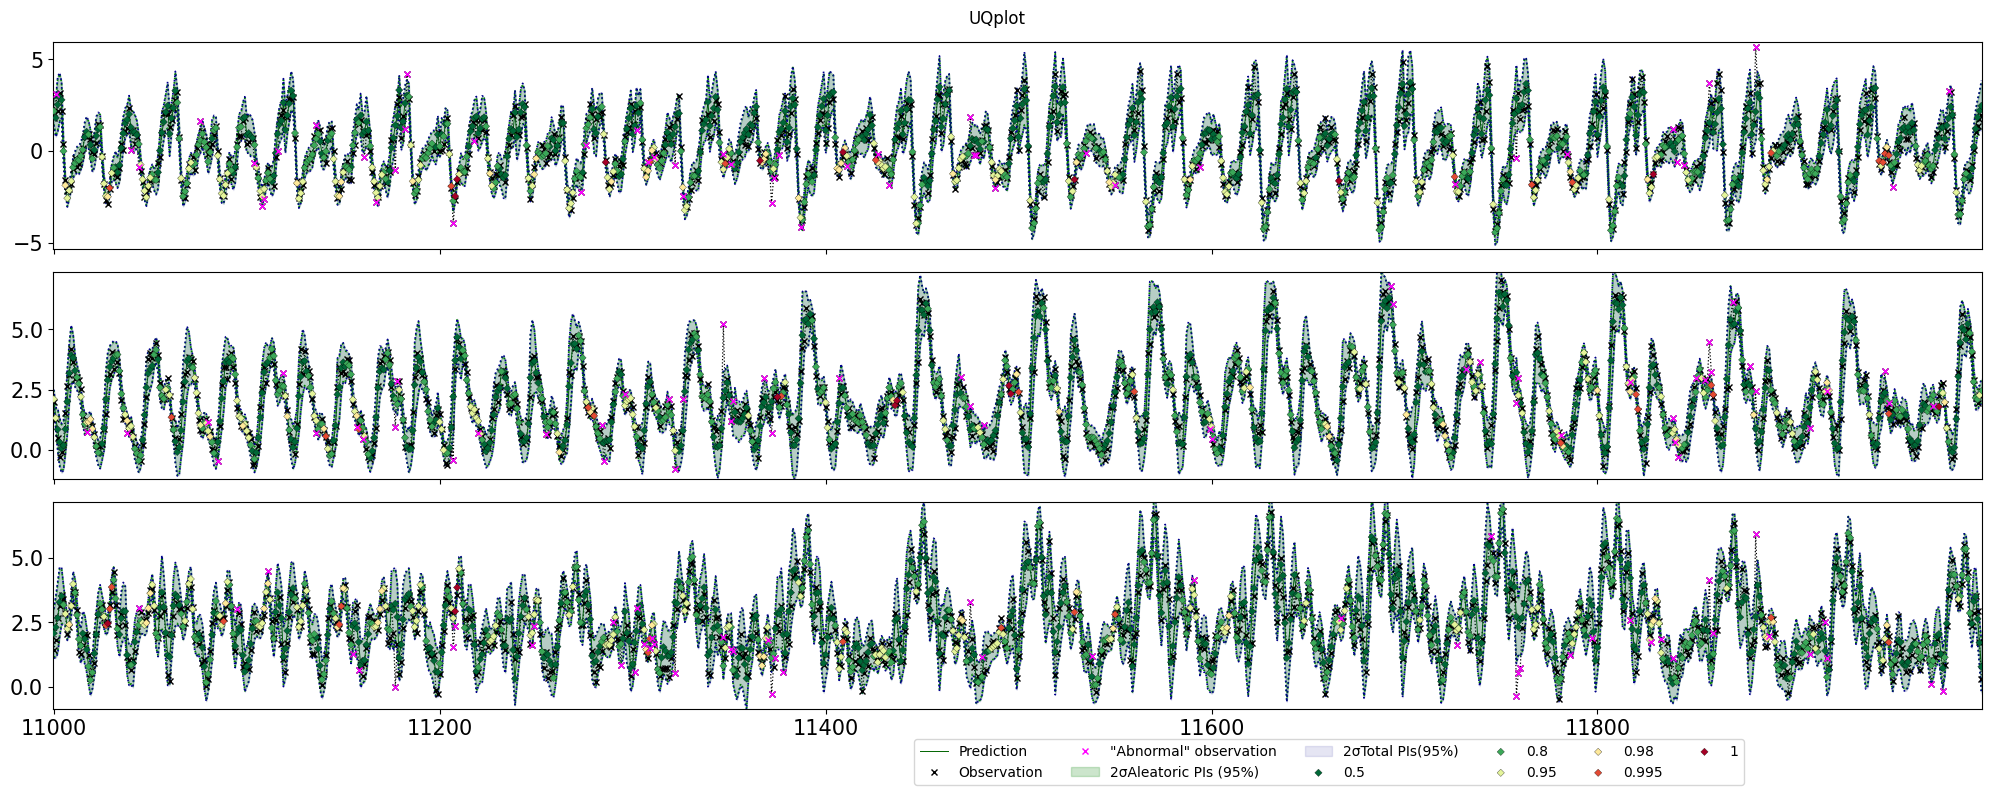

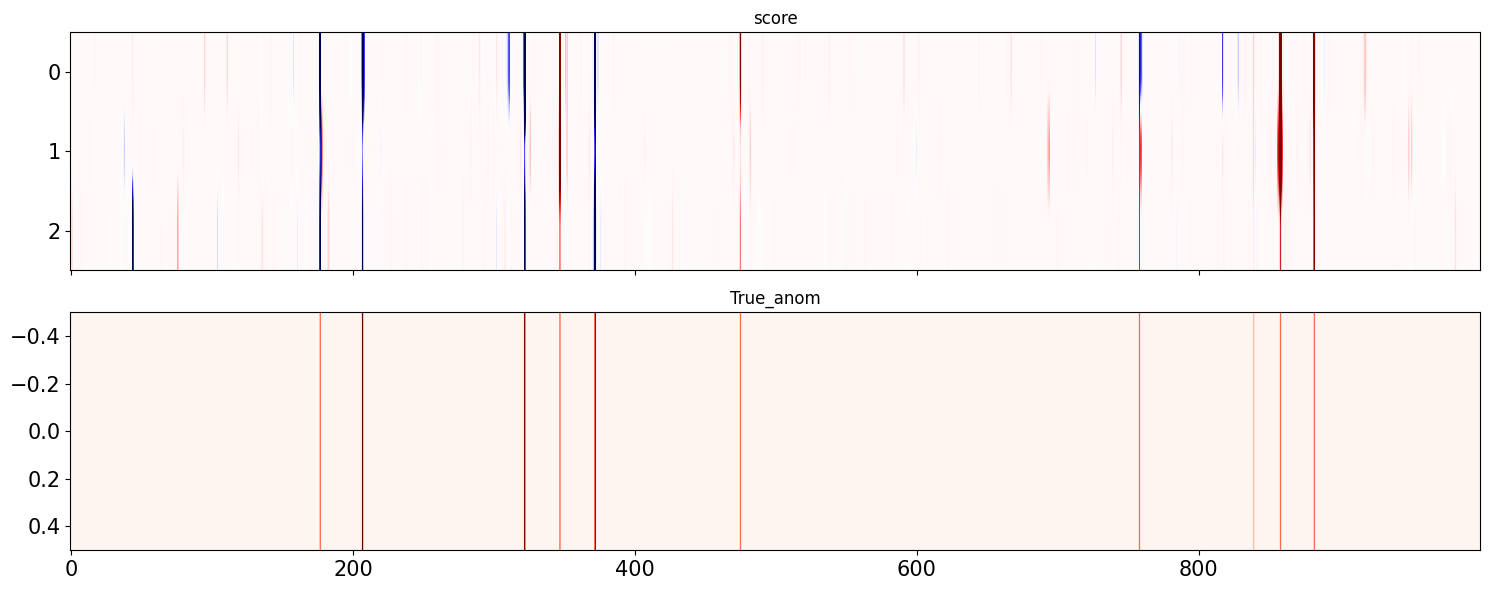

target [0.025, 0.16, 0.84, 0.975] empirique [0.01888888888888889, 0.12166666666666667, 0.9075555555555556, 0.9851944444444445]
target elvl [0.5, 0.8, 0.95, 0.98, 0.995, 1] empirique Elvl [0.0, 1.0, 2.0, 3.0, 4.0, 6.0]
[0.5, 0.8, 0.95, 0.98, 0.995, 1]


In [10]:
run_mlp(type_output='EDL')

# LSTM_ED_UQ mutlihorizon forecast as UQEstimator

In [11]:
from uqmodels.modelization.DL_estimator.lstm_ed import Lstm_ED_UQ,get_params_dict
from uqmodels.modelization.UQEstimator import get_UQEstimator_parameters
from uqmodels.custom_UQModel import UQModel, UQModel_KPI
from uqmodels.modelization.DL_estimator.neural_network_UQ import get_training_parameters

name = 'LSTM_ED'
type_output = 'MC_Dropout'
model_params = get_params_dict(dim_ctx=X.shape[-1], dim_dyn=y.shape[-1],dim_target=y.shape[-1],size_window=40,n_windows=10,dim_horizon=5,dim_chan=1,type_output='MC_Dropout')
training_param = get_training_parameters(epochs=[20,10],b_s=[128,64],l_r=[0.001,0.0005],list_loss=['MSE','BNN'],metrics=['MSE','BNN'],param_loss=[2,0.9])
UQEstimator_initializer = Lstm_ED_UQ

UQEstimator_parameters = get_UQEstimator_parameters(model_parameters=model_params, 
                                                    training_parameters=training_param,
                                                    type_output=type_output,
                                                    factory_parameters= {'factory_lag_st':0,'factory_lag_lt':0},
                                                    rescale=False)


# We can also create a more complexe UQmodel that handle several UQKPI_Processor to build at inference (UQMesure, Predictive interval and model unreliability score) and after observation (Anomaly score)

# Specification of the UQestimator
UQEstimator_initializer = UQEstimator_initializer
UQEstimator_parameters = UQEstimator_parameters

# Instanciation of the UQmodel modeling pipeline
DEEP_UQModel = UQModel_KPI(UQEstimator_initializer,
                           UQEstimator_parameters,
                           name=name, 
                           predictor=None,
                           beta=0.001,reduc_filter_KPI=[1,1,1,1,1],
                           reduc_filter_pred=[1,0,0,0,0],
                           random_state=0)

# Fit procedure

# Apply factory at begin on all sub-sequences, then learning using folded representation : lot of space memory / less time consuming
DEEP_UQModel._init_UQEstimator((X[train],y[train]),y[train])

# Afactory function turn sequence in Window with mutli-horizon prediction
# Manipulate sequence and apply factory on each batch : Less space memory / more time consuming
if True : # For test purpose run both mode
    DEEP_UQModel.UQEstimator.training_parameters['generator']=True
    DEEP_UQModel.fit([X[train],y[train]],y[train],verbose=1)
    pred,(UQ,PIs,Elvl) = DEEP_UQModel.predict((X,y))
    (pred,UQ),KPI_anom,PIs,Elvl = DEEP_UQModel.score((X,y),y)

# Apply factory on all sub-sequences, then learning on batch representation : lot of space memory / less time consuming
if True :
    DEEP_UQModel.UQEstimator.training_parameters['generator']=False
    DEEP_UQModel._init_UQEstimator((X[train],y[train]),y[train])
    DEEP_UQModel.fit([X[train],y[train]],y[train],verbose=1)
    if(True): # Test save load procedure 
        DEEP_UQModel.save('model/')
        del DEEP_UQModel
        DEEP_UQModel = UQModel()
        DEEP_UQModel.load('model/'+name)
    pred,(UQ,PIs,Elvl) = DEEP_UQModel.predict((X,y))
    (pred,UQ),KPI_anom,PIs,Elvl = DEEP_UQModel.score((X,y),y)
# Inference procedure that provide prediction plus the specified UQKPIs


from uqmodels.evaluation.metrics import Generic_metric, rmse, UQ_average_coverage, UQ_sharpness, UQ_Gaussian_NLL, UQ_dEI, UQ_absolute_residu_score
from uqmodels.evaluation.evaluation import evaluate
if(True):
    list_metrics=[Generic_metric(rmse,'Root mean square',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E'),
                  Generic_metric(UQ_average_coverage,'UQ_average_coverage',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E')]
    output = pred,UQ
    metrics_val = evaluate(y,output,list_metrics,list_sets=[train,test],verbose=True)
    


start_fit
<class 'keras.src.backend.common.keras_tensor.KerasTensor'> <class 'keras.src.backend.common.keras_tensor.KerasTensor'>


/home/jovyan/Maturation/env-uqmodels/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/20


/home/jovyan/Maturation/env-uqmodels/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
E0000 00:00:1764952202.919909  580693 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/mouving_conv__embedding_1/dropout_45_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1764952204.653220  581126 cuda_dnn.cc:529] Loaded cuDNN version 90300


57/57 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step - bnn_loss: 0.6521 - loss: 2.8506 - mse_loss: 1.6431 - val_bnn_loss: 0.6717 - val_loss: 2.1936 - val_mse_loss: 1.4693 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - bnn_loss: 0.6595 - loss: 2.4374 - mse_loss: 1.5382 - val_bnn_loss: 0.7239 - val_loss: 1.8957 - val_mse_loss: 1.3638 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - bnn_loss: 0.7647 - loss: 1.6228 - mse_loss: 1.3004 - val_bnn_loss: 0.8166 - val_loss: 1.1858 - val_mse_loss: 1.1381 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - bnn_loss: 0.8322 - loss: 1.2559 - mse_loss: 1.1783 - val_bnn_loss: 0.8947 - val_loss: 0.9616 - val_mse_loss: 1.0514 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - bnn_loss: 0.8730 - loss: 1.0406 - mse_loss: 1.0877 - val_bnn_loss: 0.9228 - val_loss: 0.7557 - val_mse_loss: 0.9276 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms

...

113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - bnn_loss: 0.9658 - loss: -0.5446 - mse_loss: 0.4530 - val_bnn_loss: 0.9732 - val_loss: -0.6498 - val_mse_loss: 0.4054 - learning_rate: 5.0000e-04
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - bnn_loss: 0.9655 - loss: -0.5479 - mse_loss: 0.4524 - val_bnn_loss: 0.9689 - val_loss: -0.5892 - val_mse_loss: 0.4183 - learning_rate: 5.0000e-04
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - bnn_loss: 0.9663 - loss: -0.5494 - mse_loss: 0.4502 - val_bnn_loss: 0.9743 - val_loss: -0.6423 - val_mse_loss: 0.4109 - learning_rate: 5.0000e-04
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - bnn_loss: 0.9662 - loss: -0.5541 - mse_loss: 0.4502 - val_bnn_loss: 0.9735 - val_loss: -0.6382 - val_mse_loss: 0.4057 - learning_rate: 5.0000e-04
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - bnn_loss: 0.9660 - loss: -0.5623 - mse_loss: 0.4491 - val_bnn_loss: 0.9752 - val_loss: -0.6805 - val_mse_loss: 0.4011 - learning_rate: 5.0000e-04
Epoch

/home/jovyan/Maturation/env-uqmodels/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'mouving_conv__embedding_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/jovyan/Maturation/env-uqmodels/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 28 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


<class 'keras.src.backend.common.keras_tensor.KerasTensor'> <class 'keras.src.backend.common.keras_tensor.KerasTensor'>
  1/375 ━━━━━━━━━━━━━━━━━━━━ 5:28 878ms/step

E0000 00:00:1764952768.837459  580693 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_1_1/mouving_conv__embedding_2_1/dropout_63_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Root mean square [array([0.42711375, 0.38954128, 0.41023743]), array([0.4589698 , 0.40827596, 0.43964719])]
UQ_average_coverage [array([0.9785  , 0.978625, 0.97925 ]), array([0.97275, 0.9735 , 0.96925])]


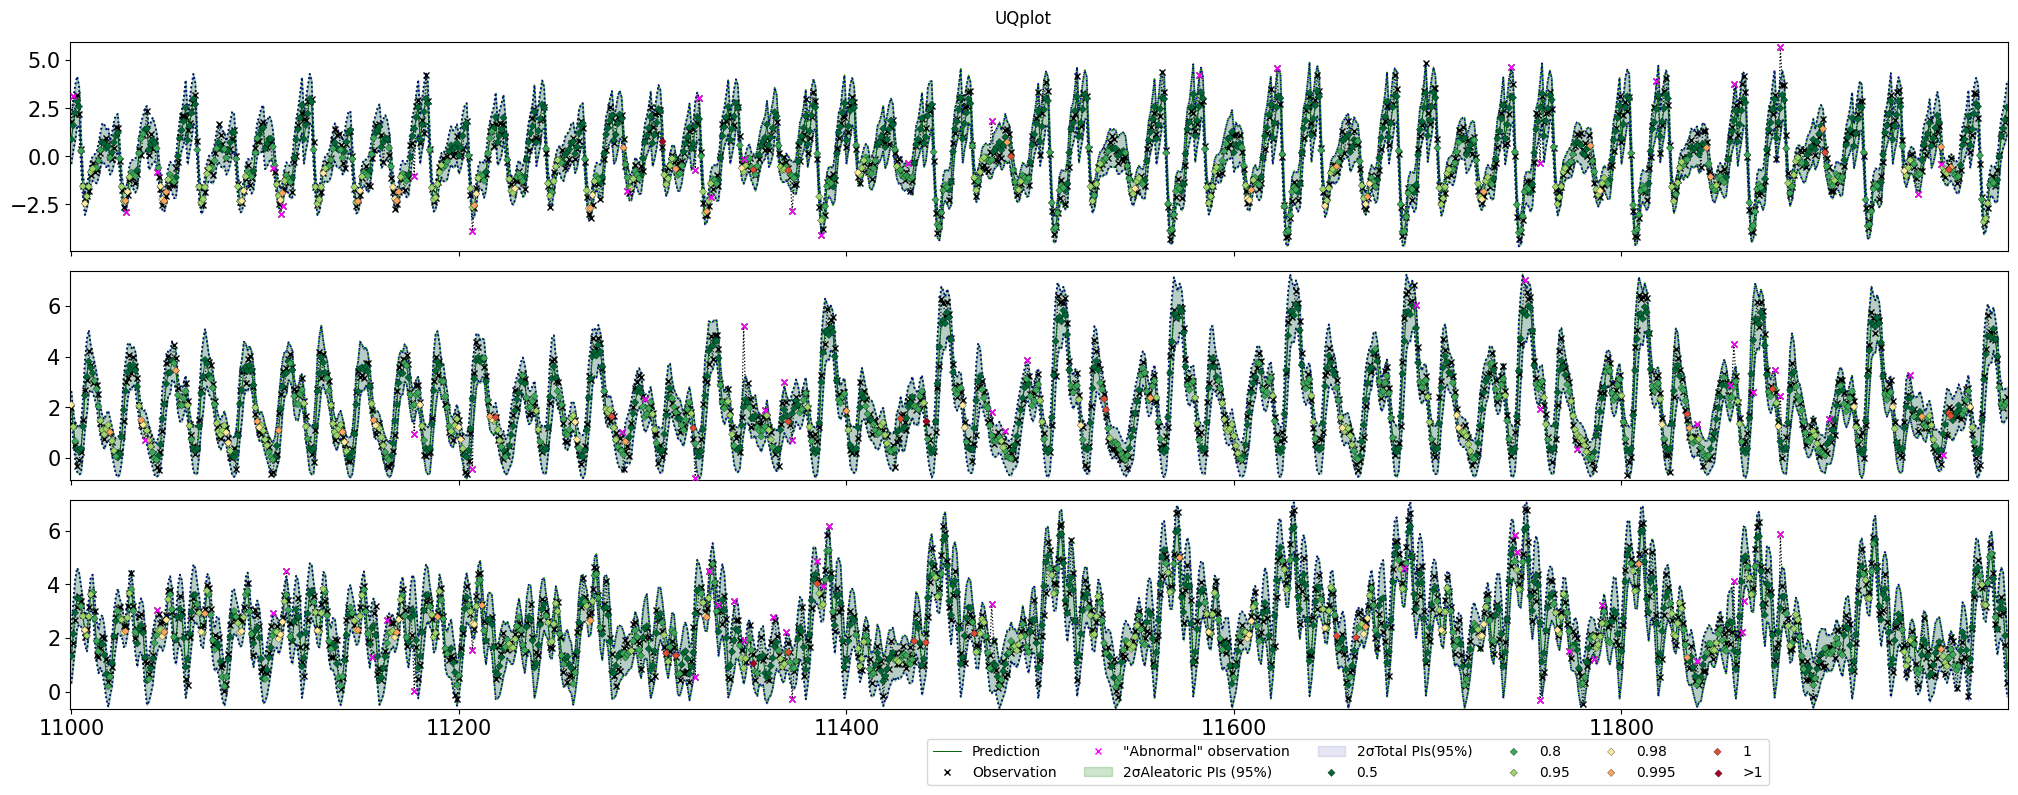

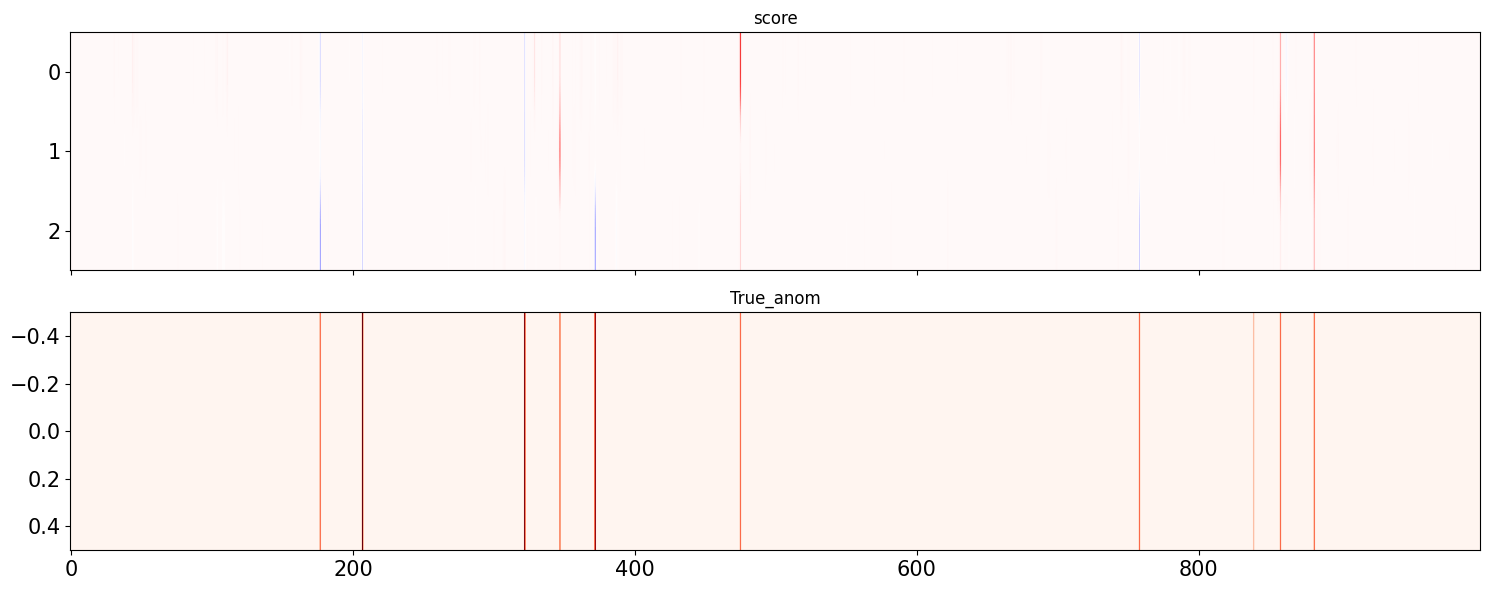

target [0.025, 0.16, 0.84, 0.975] empirique [0.010555555555555556, 0.09025, 0.8550833333333333, 0.9844444444444445]
target elvl [0.5, 0.8, 0.95, 0.98, 0.995, 1] empirique Elvl [0.0, 1.0, 2.0, 3.0, 5.0, 6.0]


In [12]:
%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import uqmodels.visualization.visualization as visu

f_obs = np.arange(len(train))[-1000:]

list_percent = DEEP_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
visu.uncertainty_plot(y,output,context=None,size=(20,8),f_obs=f_obs,name='UQplot',mode_res=False,dim=np.arange(y.shape[1]),type_UQ=DEEP_UQModel.type_UQ,confidence_lvl=Elvl,list_percent=list_percent)
visu.plot_anom_matrice(score=KPI_anom,true_label=dict_data['aux']['anom'][:,None],f_obs=f_obs)

list_alpha = DEEP_UQModel.list_predict_KPI_processors[1].KPI_parameters['list_alpha']
print('target', list_alpha, 'empirique', [(pi>y).mean() for pi in PIs])
list_percent = DEEP_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
print('target elvl',list_percent,'empirique Elvl',[np.quantile(Elvl,q) for q in list_percent])
del DEEP_UQModel

In [13]:
# LSTM_ED_UQ mutlihorizon forecast as UQEstimator

In [16]:
from uqmodels.modelization.DL_estimator.loss import build_BNN_loss, build_MSE_loss, default_callbacks
from uqmodels.modelization.DL_estimator.transformer_ed import Transformer_ED_UQ,get_params_dict
from uqmodels.custom_UQModel import UQModel, UQModel_KPI

name = 'Transformer_ED'
type_output = 'MC_Dropout'
model_params = get_params_dict(dim_ctx=X.shape[-1],dim_dyn=y.shape[-1],dim_target=y.shape[-1],size_window=40,n_windows=10,dim_horizon=5)
training_param = get_training_parameters(epochs=[20,10],b_s=[128],l_r=[0.001,0.0005],list_loss=['MSE','BNN'],metrics=['MSE','BNN'],param_loss=[2,0.9])
UQEstimator_initializer = Transformer_ED_UQ
UQEstimator_parameters = get_UQEstimator_parameters(model_parameters=model_params, 
                                                    training_parameters=training_param,
                                                    type_output=type_output,
                                                    factory_parameters= {'factory_lag_st':0,'factory_lag_lt':0},
                                                    rescale=False)


from uqmodels.custom_UQModel import UQModel_KPI
# We can also create a more complexe UQmodel that handle several UQKPI_Processor to build at inference (UQMesure, Predictive interval and model unreliability score) and after observation (Anomaly score)

# Specification of the UQestimator
UQEstimator_initializer = UQEstimator_initializer
UQEstimator_parameters = UQEstimator_parameters

# Instanciation of the UQmodel modeling pipeline
DEEP_UQModel = UQModel_KPI(UQEstimator_initializer,
                           UQEstimator_parameters,
                           name=name,
                           predictor=None,
                           beta=0.001,
                           reduc_filter_KPI=[1,1,1,1,1],
                           reduc_filter_pred=[1,0,0,0,0],
                           random_state=0)

# Fit procedure

# Apply factory at begin on all sub-sequences, then learning using folded representation : lot of space memory / less time consuming
DEEP_UQModel._init_UQEstimator((X[train],y[train]),y[train])

# Afactory function turn sequence in Window with mutli-horizon prediction
# Manipulate sequence and apply factory on each batch : Less space memory / more time consuming
if True : # For test purpose run both mode
    DEEP_UQModel.UQEstimator.training_parameters['generator']=True
    DEEP_UQModel.fit([X[train],y[train]],y[train],verbose=1)
    pred,(UQ,PIs,Elvl) = DEEP_UQModel.predict((X,y))
    (pred,UQ),KPI_anom,PIs,Elvl = DEEP_UQModel.score((X,y),y)

# Apply factory on all sub-sequences, then learning on batch representation : lot of space memory / less time consuming
if True :
    DEEP_UQModel.UQEstimator.training_parameters['generator']=False
    DEEP_UQModel.fit([X[train],y[train]],y[train],verbose=1)
    if(False): # Test save load procedure : issues laading procedure run but doesn't load an operational model 
        DEEP_UQModel.save('model/')
        DEEP_UQModel = UQModel()
        DEEP_UQModel.load('model/'+name+'/')
    pred,(UQ,PIs,Elvl) = DEEP_UQModel.predict((X,y))
    (pred,UQ),KPI_anom,PIs,Elvl = DEEP_UQModel.score((X,y),y)

# Inference procedure that provide prediction plus the specified UQKPIs
#pred,((pred,UQ),PIs,Elvl) = DEEP_UQModel.predict([X[train],y[train]])
# Score procedure that provide ANom-KPI

from uqmodels.evaluation.metrics import Generic_metric, rmse, UQ_average_coverage, UQ_sharpness, UQ_Gaussian_NLL, UQ_dEI, UQ_absolute_residu_score
from uqmodels.evaluation.evaluation import evaluate

list_metrics=[Generic_metric(rmse,'Root mean square',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E'),
              Generic_metric(UQ_average_coverage,'UQ_average_coverage',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E')]
output = pred,UQ
metrics_val = evaluate(y,output,list_metrics,list_sets=[train,test],verbose=True)




start_fit
Epoch 1/20


E0000 00:00:1764953011.140719  580693 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/model_1/mouving_conv__embedding_3_1/dropout_75_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


57/57 ━━━━━━━━━━━━━━━━━━━━ 28s 75ms/step - bnn_loss: 0.7952 - loss: 1.7784 - mse_loss: 1.3454 - val_bnn_loss: 0.8548 - val_loss: 1.0137 - val_mse_loss: 1.1274 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - bnn_loss: 0.8653 - loss: 1.0065 - mse_loss: 1.0844 - val_bnn_loss: 0.9221 - val_loss: 0.7001 - val_mse_loss: 0.8546 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - bnn_loss: 0.8950 - loss: 0.7981 - mse_loss: 0.8967 - val_bnn_loss: 0.9486 - val_loss: 0.5368 - val_mse_loss: 0.7704 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - bnn_loss: 0.9139 - loss: 0.6927 - mse_loss: 0.8158 - val_bnn_loss: 0.9445 - val_loss: 0.5159 - val_mse_loss: 0.7087 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - bnn_loss: 0.9287 - loss: 0.6209 - mse_loss: 0.7599 - val_bnn_loss: 0.9677 - val_loss: 0.4229 - val_mse_loss: 0.6268 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms

E0000 00:00:1764953089.064003  580693 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/model_1/mouving_conv__embedding_3_1/dropout_75_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


57/57 ━━━━━━━━━━━━━━━━━━━━ 30s 73ms/step - bnn_loss: 0.9696 - loss: 0.1346 - mse_loss: 0.5636 - val_bnn_loss: 0.9895 - val_loss: -0.3581 - val_mse_loss: 0.4319 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - bnn_loss: 0.9680 - loss: -0.1348 - mse_loss: 0.5169 - val_bnn_loss: 0.9815 - val_loss: -0.3941 - val_mse_loss: 0.4312 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - bnn_loss: 0.9668 - loss: -0.1948 - mse_loss: 0.5082 - val_bnn_loss: 0.9843 - val_loss: -0.4996 - val_mse_loss: 0.4310 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - bnn_loss: 0.9660 - loss: -0.1805 - mse_loss: 0.5121 - val_bnn_loss: 0.9853 - val_loss: -0.4645 - val_mse_loss: 0.4319 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - bnn_loss: 0.9644 - loss: -0.2004 - mse_loss: 0.5095 - val_bnn_loss: 0.9859 - val_loss: -0.4666 - val_mse_loss: 0.4304 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━

...

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - bnn_loss: 0.9558 - loss: -0.0143 - mse_loss: 0.4833

2025-12-05 16:47:56.042181: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


57/57 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - bnn_loss: 0.9665 - loss: -0.3567 - mse_loss: 0.4520 - val_bnn_loss: 0.9771 - val_loss: -0.6637 - val_mse_loss: 0.3903 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - bnn_loss: 0.9670 - loss: -0.5444 - mse_loss: 0.4339 - val_bnn_loss: 0.9778 - val_loss: -0.6907 - val_mse_loss: 0.3876 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - bnn_loss: 0.9664 - loss: -0.5357 - mse_loss: 0.4394 - val_bnn_loss: 0.9815 - val_loss: -0.6195 - val_mse_loss: 0.3971 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - bnn_loss: 0.9674 - loss: -0.5480 - mse_loss: 0.4362 - val_bnn_loss: 0.9777 - val_loss: -0.7217 - val_mse_loss: 0.3828 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - bnn_loss: 0.9673 - loss: -0.5562 - mse_loss: 0.4341 - val_bnn_loss: 0.9763 - val_loss: -0.6973 - val_mse_loss: 0.3880 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━

E0000 00:00:1764953334.436065  580693 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_1/mouving_conv__embedding_3_1/dropout_76_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Root mean square [array([0.42014995, 0.36845627, 0.40326475]), array([0.4558244 , 0.39407298, 0.43009912])]
UQ_average_coverage [array([0.979125, 0.979   , 0.98    ]), array([0.966  , 0.97275, 0.96925])]


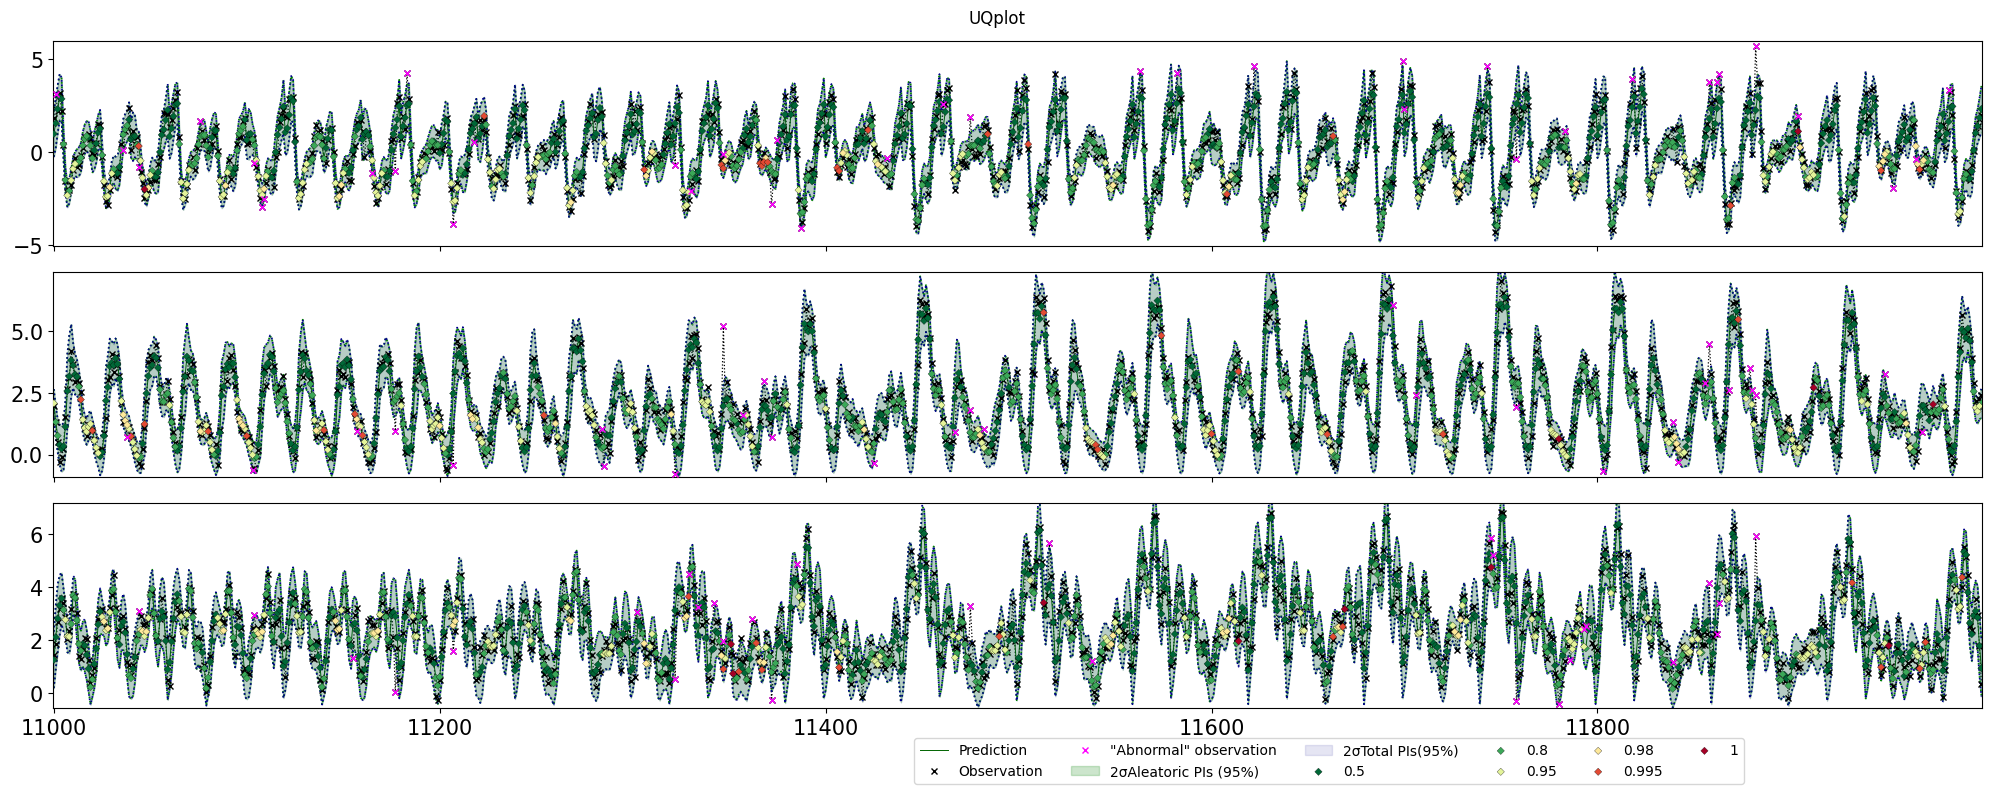

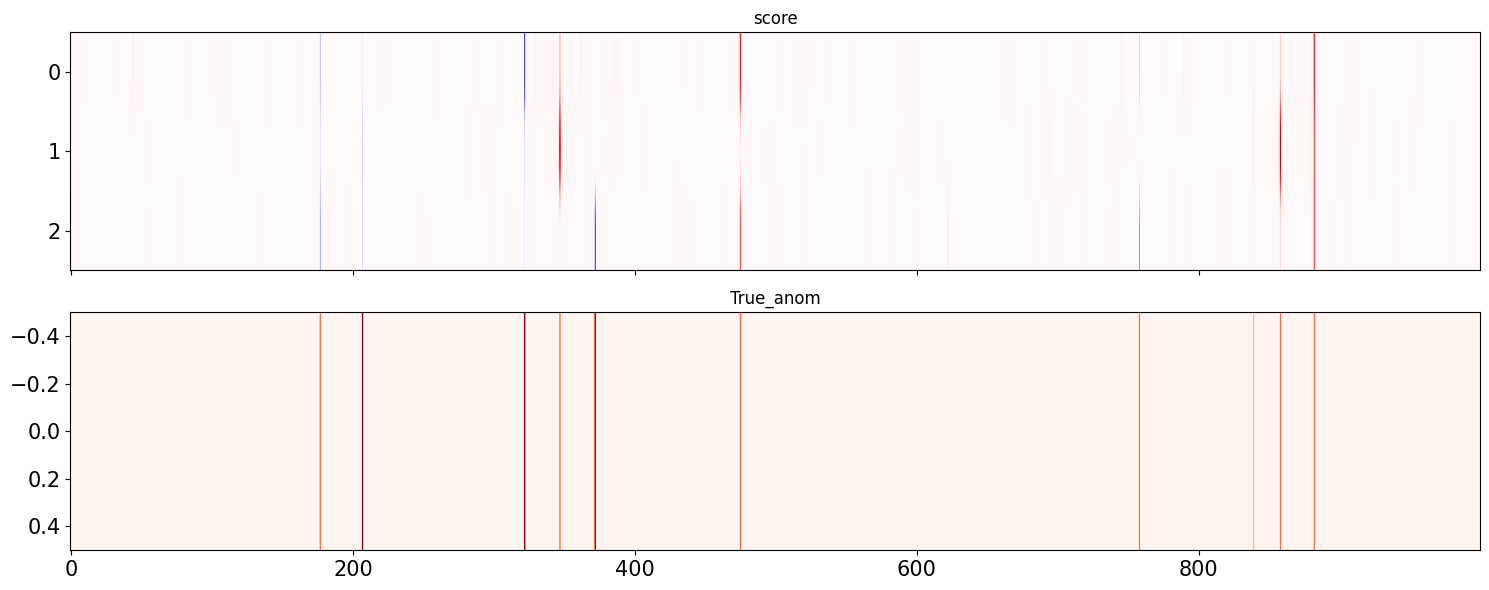

target [0.025, 0.16, 0.84, 0.975] empirique [0.010277777777777778, 0.08386111111111111, 0.8593055555555555, 0.9841388888888889]
target elvl [0.5, 0.8, 0.95, 0.98, 0.995, 1] empirique Elvl [1.0, 2.0, 3.0, 4.0, 5.0, 5.0]


In [17]:
%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import uqmodels.visualization.visualization as visu

f_obs = np.arange(len(train))[-1000:]

list_percent = DEEP_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
visu.uncertainty_plot(y,output,context=None,size=(20,8),f_obs=f_obs,name='UQplot',mode_res=False,dim=np.arange(y.shape[1]),type_UQ=DEEP_UQModel.type_UQ,confidence_lvl=Elvl,list_percent=list_percent)
visu.plot_anom_matrice(score=KPI_anom,true_label=dict_data['aux']['anom'][:,None],f_obs=f_obs)

list_alpha = DEEP_UQModel.list_predict_KPI_processors[1].KPI_parameters['list_alpha']
print('target', list_alpha, 'empirique', [(pi>y).mean() for pi in PIs])
list_percent = DEEP_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
print('target elvl',list_percent,'empirique Elvl',[np.quantile(Elvl,q) for q in list_percent])


In [18]:
del DEEP_UQModel